Modularity score: 0.429


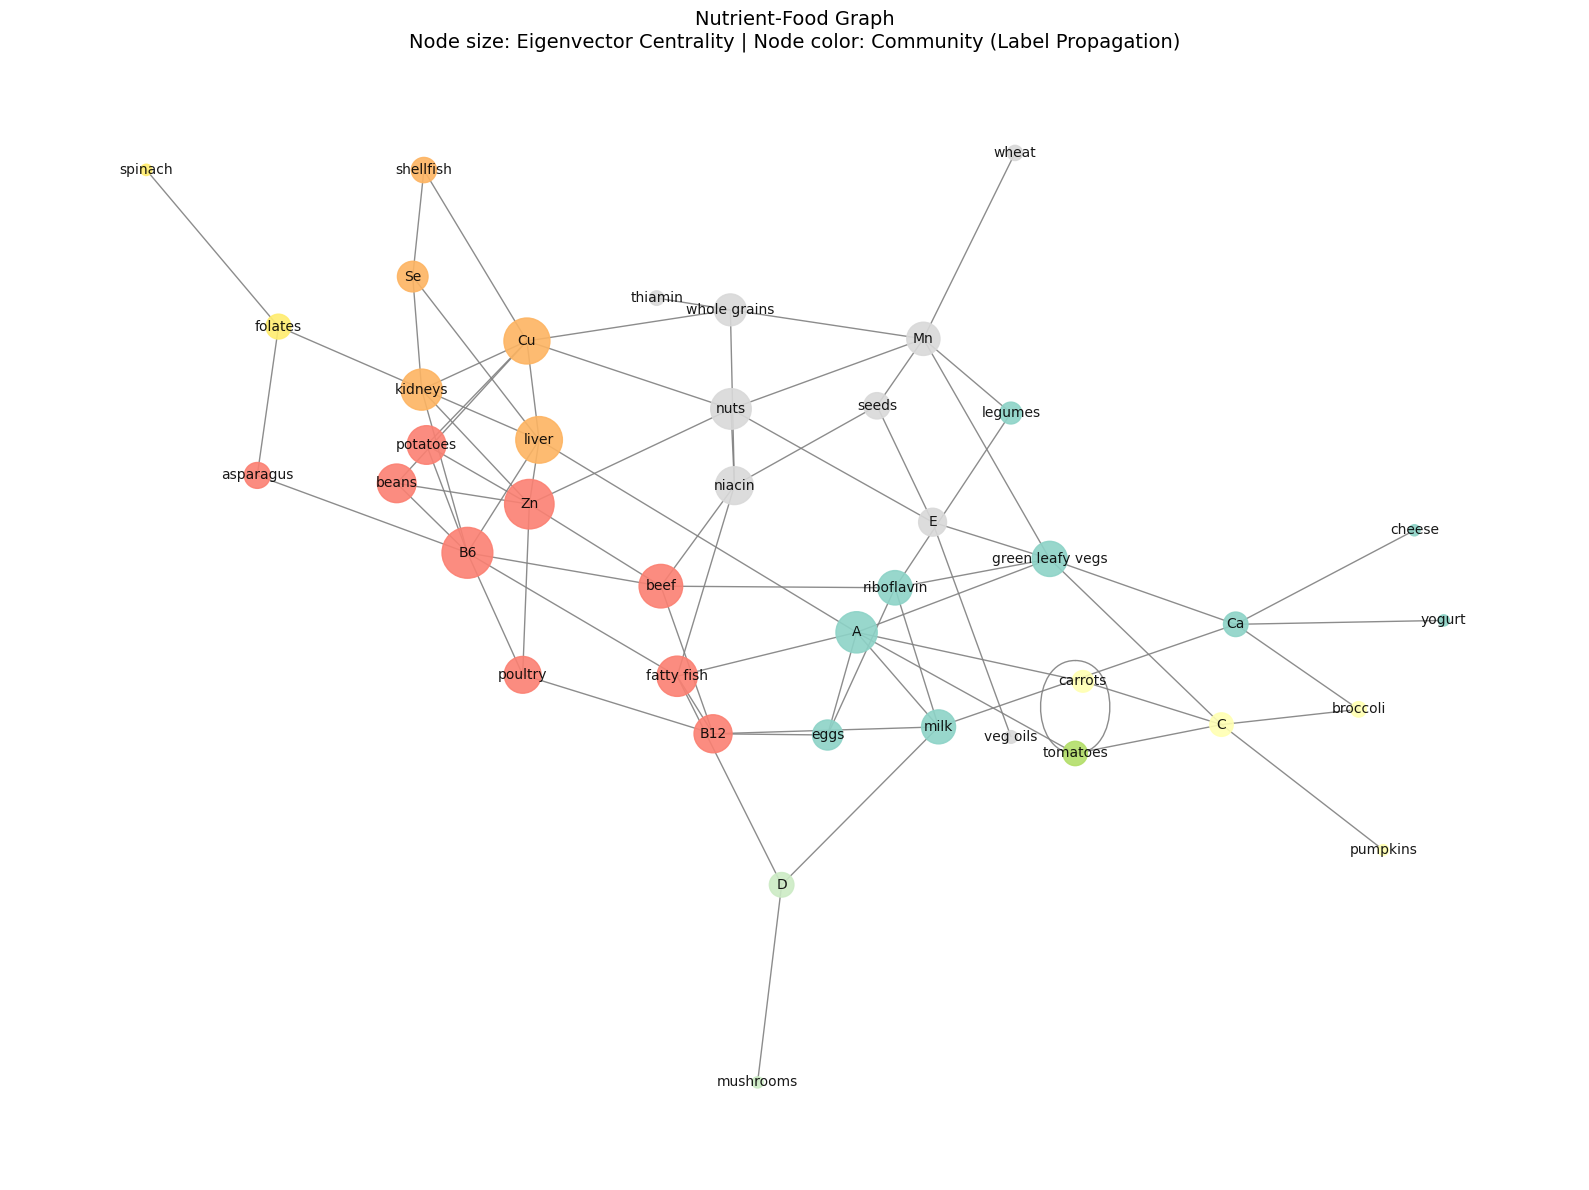

In [1]:
# !pip install first
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import label_propagation_communities, modularity

# Load your data
df = pd.read_csv('nutrients.csv', header=None, names=['Nutrient', 'Food'])

# Clean up quotes from some entries
df['Food'] = df['Food'].str.strip('"')

# Create graph
G = nx.from_pandas_edgelist(df, source='Nutrient', target='Food')

# Centrality Measures
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Community Detection
communities = list(label_propagation_communities(G))
community_map = {node: i for i, com in enumerate(communities) for node in com}

# Modularity Calculation
Q = modularity(G, communities)
print(f"Modularity score: {Q:.3f}")

# Visualization parameters
node_colors = [community_map[node] for node in G.nodes()]
node_sizes = [4000 * eigenvector_centrality[node] for node in G.nodes()]  # scale for visibility

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw the graph
plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.Set3,
    with_labels=True,
    edge_color='gray',
    font_size=10,
    alpha=0.9
)

plt.title("Nutrient-Food Graph\nNode size: Eigenvector Centrality | Node color: Community (Label Propagation)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()